In [ ]:
using LinearAlgebra
include("pde_model.jl")
include("main.jl")

compute_BC_corr

In [30]:
using JSON
metadata = JSON.parsefile("temp/metadata.json")
type = metadata["type"]
n = metadata["n"]
d = metadata["d"]
FType = get_FloatType(metadata["ft"])
nt = metadata["nt"]
t_max = metadata["t_max"]

1.0

In [6]:
u_fun = create_u_fun(d,Float64)
t = 0.0
U_analytic = Vector{Float64}(undef, n^d)
eval_on_grid!(n,d,U_analytic,u_fun,t);

In [31]:
using Serialization
U0 = deserialize("temp/U0.dat");
U1 = deserialize("temp/U1.dat");
UT = deserialize("temp/UT.dat");

In [10]:
using CairoMakie

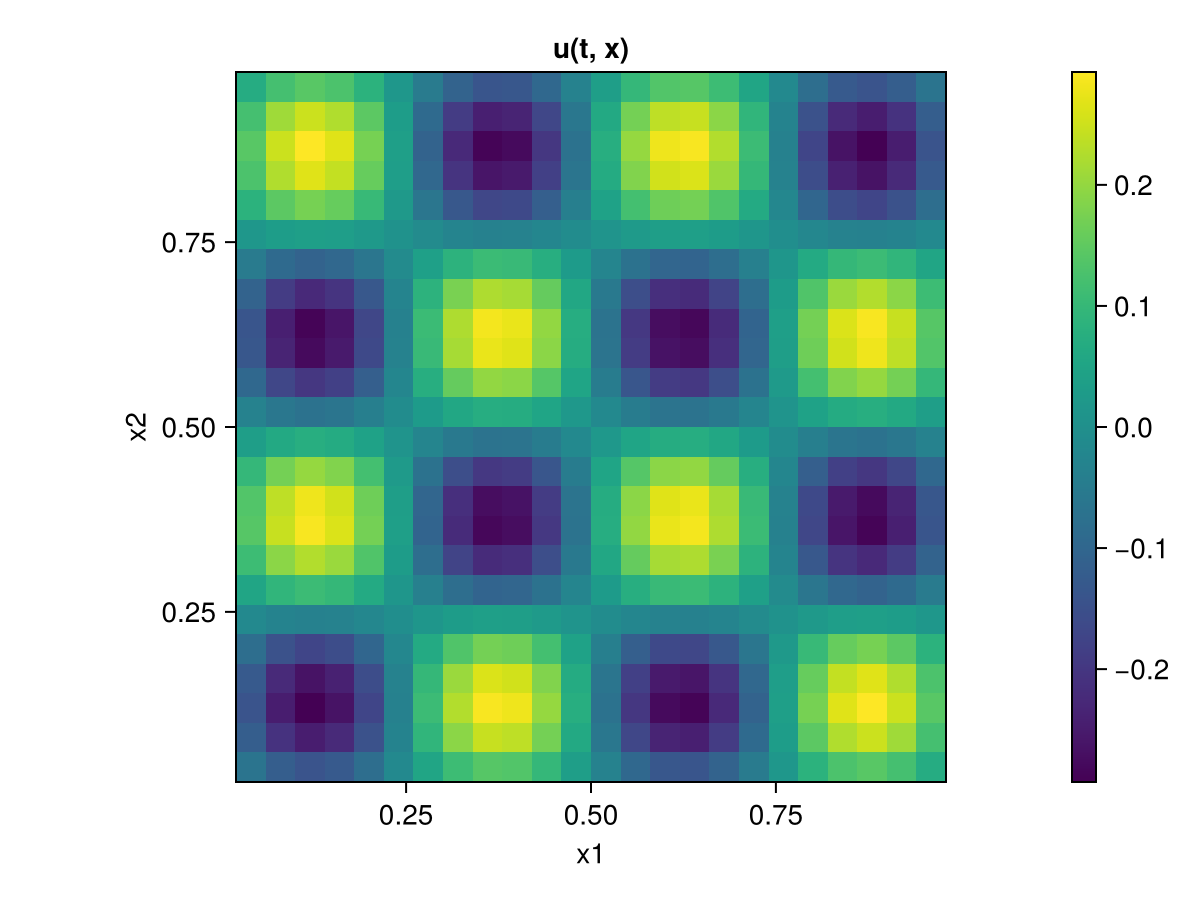

In [33]:
#ti = 1
#tau = 1/(n_iters-1)
#t = (ti-1) * tau
h = 1/(n+1)

Ut = U_analytic
Ut = UT
xs = range(h, 1-h; length=n)
U_matrix = reshape(Ut, ntuple(_ -> n, d)...)

fig, ax, hm = heatmap(xs, xs, U_matrix,
    colormap = :viridis,
    #axis = (title = "u(t, x)  |  t = $t, t in [0, $t_max]", xlabel = "x1", ylabel = "x2", aspect = 1)
    axis = (title = "u(t, x)", xlabel = "x1", ylabel = "x2", aspect = 1)
)
Colorbar(fig[1, 2], hm)
fig

---